In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from scipy import stats

famExp = pd.read_csv('clean_fam_expenditures.csv')
famExp

,Total Household Income,Region,Total Food Expenditure,Main Source of Income,Agricultural Household indicator,Bread and Cereals Expenditure,Total Rice Expenditure,Meat Expenditure,Total Fish and marine products Expenditure,Fruit Expenditure,...,Number of Refrigerator/Freezer,Number of Washing Machine,Number of Airconditioner,"Number of Car, Jeep, Van",Number of Landline/wireless telephones,Number of Cellular phone,Number of Personal Computer,Number of Stove with Oven/Gas Range,Number of Motorized Banca,Number of Motorcycle/Tricycle
0,480332,CAR,117848,Wage/Salaries,0,42140,38300,24676,16806,3325,...,1,1,0,0,0,2,1,0,0,1
1,198235,CAR,67766,Wage/Salaries,0,17329,13008,17434,11073,2035,...,0,1,0,0,0,3,1,0,0,2
2,82785,CAR,61609,Wage/Salaries,1,34182,32001,7783,2590,1730,...,0,0,0,0,0,0,0,0,0,0
3,107589,CAR,78189,Wage/Salaries,0,34030,28659,10914,10812,690,...,0,0,0,0,0,1,0,0,0,0
4,189322,CAR,94625,Wage/Salaries,0,34820,30167,18391,11309,1395,...,1,0,0,0,0,3,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41539,119773,XII - SOCCSKSARGEN,44875,Enterpreneurial Activities,1,23675,21542,1476,6120,1632,...,0,0,0,0,0,1,0,0,0,0
41540,137320,XII - SOCCSKSARGEN,31157,Enterpreneurial Activities,1,2691,1273,1886,4386,1840,...,0,0,0,0,0,3,0,0,0,0
41541,133171,XII - SOCCSKSARGEN,45882,Enterpreneurial Activities,2,28646,27339,480,4796,1232,...,0,0,0,0,0,1,0,0,0,0
41542,129500,XII - SOCCSKSARGEN,81416,Enterpreneurial Activities,1,29996,26655,2359,17730,2923,...,0,0,0,0,0,2,0,0,0,0


In [2]:
famExp.isnull().sum()

Total Household Income                           0
Region                                           0
Total Food Expenditure                           0
Main Source of Income                            0
Agricultural Household indicator                 0
Bread and Cereals Expenditure                    0
Total Rice Expenditure                           0
Meat Expenditure                                 0
Total Fish and  marine products Expenditure      0
Fruit Expenditure                                0
Vegetables Expenditure                           0
Restaurant and hotels Expenditure                0
Alcoholic Beverages Expenditure                  0
Tobacco Expenditure                              0
Clothing, Footwear and Other Wear Expenditure    0
Housing and water Expenditure                    0
Imputed House Rental Value                       0
Medical Care Expenditure                         0
Transportation Expenditure                       0
Communication Expenditure      

In [3]:
famExp[['Region']]

,Region
0,CAR
1,CAR
2,CAR
3,CAR
4,CAR
...,...
41539,XII - SOCCSKSARGEN
41540,XII - SOCCSKSARGEN
41541,XII - SOCCSKSARGEN
41542,XII - SOCCSKSARGEN


In [4]:
famExp.describe()

,Total Household Income,Total Food Expenditure,Agricultural Household indicator,Bread and Cereals Expenditure,Total Rice Expenditure,Meat Expenditure,Total Fish and marine products Expenditure,Fruit Expenditure,Vegetables Expenditure,Restaurant and hotels Expenditure,...,Number of Refrigerator/Freezer,Number of Washing Machine,Number of Airconditioner,"Number of Car, Jeep, Van",Number of Landline/wireless telephones,Number of Cellular phone,Number of Personal Computer,Number of Stove with Oven/Gas Range,Number of Motorized Banca,Number of Motorcycle/Tricycle
count,4.154400e+04,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000,...,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000,41544.000000
mean,2.475556e+05,85099.158194,0.429858,25133.723642,18195.825005,10540.072574,10529.318337,2550.474990,5006.918568,15436.566075,...,0.394184,0.319806,0.129814,0.081215,0.060610,1.905738,0.315015,0.135038,0.013119,0.289885
std,2.868805e+05,51637.947682,0.676666,13466.482984,11727.224350,10497.727757,7812.201613,2969.752879,3300.175236,23705.195929,...,0.537025,0.478482,0.448673,0.346786,0.276732,1.558130,0.739698,0.354083,0.127171,0.558408
min,1.128500e+04,2947.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.048950e+05,51017.250000,0.000000,16556.000000,11020.000000,3353.750000,5504.000000,1024.750000,2873.000000,1930.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,1.640795e+05,72985.500000,0.000000,23324.000000,16620.000000,7332.500000,8695.000000,1820.000000,4314.000000,7314.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
75%,2.911385e+05,105635.500000,1.000000,31439.000000,23920.000000,14292.000000,13388.000000,3100.000000,6304.250000,19921.250000,...,1.000000,1.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000
max,1.181599e+07,827565.000000,2.000000,765864.000000,758326.000000,261566.000000,188208.000000,273769.000000,74800.000000,725296.000000,...,5.000000,3.000000,5.000000,5.000000,4.000000,10.000000,6.000000,3.000000,3.000000,5.000000


In [5]:
famExp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41544 entries, 0 to 41543
Data columns (total 60 columns):
 #   Column                                         Non-Null Count  Dtype 
---  ------                                         --------------  ----- 
 0   Total Household Income                         41544 non-null  int64 
 1   Region                                         41544 non-null  object
 2   Total Food Expenditure                         41544 non-null  int64 
 3   Main Source of Income                          41544 non-null  object
 4   Agricultural Household indicator               41544 non-null  int64 
 5   Bread and Cereals Expenditure                  41544 non-null  int64 
 6   Total Rice Expenditure                         41544 non-null  int64 
 7   Meat Expenditure                               41544 non-null  int64 
 8   Total Fish and  marine products Expenditure    41544 non-null  int64 
 9   Fruit Expenditure                              41544 non-null

In [6]:
famExp[famExp['Region']=='IVA - CALABARZON']

,Total Household Income,Region,Total Food Expenditure,Main Source of Income,Agricultural Household indicator,Bread and Cereals Expenditure,Total Rice Expenditure,Meat Expenditure,Total Fish and marine products Expenditure,Fruit Expenditure,...,Number of Refrigerator/Freezer,Number of Washing Machine,Number of Airconditioner,"Number of Car, Jeep, Van",Number of Landline/wireless telephones,Number of Cellular phone,Number of Personal Computer,Number of Stove with Oven/Gas Range,Number of Motorized Banca,Number of Motorcycle/Tricycle
2520,118410,IVA - CALABARZON,71019,Wage/Salaries,0,27477,24160,10688,10280,1090,...,0,0,0,0,0,2,0,0,0,0
2521,151380,IVA - CALABARZON,80889,Wage/Salaries,0,26307,22600,14007,6578,1790,...,0,1,0,0,0,2,0,0,0,0
2522,282373,IVA - CALABARZON,112023,Wage/Salaries,0,32817,29250,18110,13496,850,...,0,1,0,0,0,2,1,0,0,0
2523,146190,IVA - CALABARZON,77491,Wage/Salaries,0,20390,14313,15072,9682,1310,...,0,0,0,0,0,1,0,0,0,1
2524,95530,IVA - CALABARZON,67688,Other sources of Income,0,28642,26000,13429,5024,850,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30625,224016,IVA - CALABARZON,114730,Wage/Salaries,0,23401,18980,15745,16790,1270,...,1,0,0,0,0,3,0,0,0,0
30626,351448,IVA - CALABARZON,129143,Other sources of Income,0,21432,16060,45470,9691,1210,...,1,1,0,0,1,4,5,0,0,0
30627,191092,IVA - CALABARZON,82154,Wage/Salaries,0,20979,16588,9620,5813,2523,...,1,0,0,0,0,4,0,0,0,0
30628,549970,IVA - CALABARZON,140874,Other sources of Income,0,21097,17521,12372,20394,13748,...,0,1,0,0,1,6,1,0,0,0


<h1>PHASE 1: PREP AND CLEANING</h1>

In [7]:
# Start from your original famExp
df = famExp.copy()

# Filter regions using EXACT names from your data
target_regions = ['NCR', 'IVA - CALABARZON']
df = df[df['Region'].isin(target_regions)].copy()

# Insight #1
total = len(df)
ncr_n = len(df[df['Region'] == 'NCR'])
cal_n = len(df[df['Region'] == 'IVA - CALABARZON'])

print("📊 Insight #1: Regional Representation")
print(f"• Total households: {total:,}")
print(f"• NCR: {ncr_n:,} ({ncr_n/total:.1%})")
print(f"• IVA - CALABARZON: {cal_n:,} ({cal_n/total:.1%})")
print("\n→ Nearly balanced sample between NCR and CALABARZON.")

📊 Insight #1: Regional Representation
• Total households: 8,292
• NCR: 4,130 (49.8%)
• IVA - CALABARZON: 4,162 (50.2%)

→ Nearly balanced sample between NCR and CALABARZON.


In [8]:
# Required columns (using YOUR exact names)
required = [
    'Total Household Income',
    'Total Food Expenditure',
    'Housing and water Expenditure',
    'Tenure Status',
    'Household Head Highest Grade Completed',
    'Main Source of Income'  # already categorical
]

print("Missing values in key columns:")
print(df[required].isnull().sum())

# Filter valid economic records
df = df[
    (df['Total Household Income'] > 0) &
    (df['Total Food Expenditure'] >= 0) &
    (df['Housing and water Expenditure'] >= 0)
].copy()

# Insight #2
complete = df[required].dropna().shape[0]
pct = complete / len(df) * 100

print(f"\n📊 Insight #2: Data Completeness")
print(f"• Complete records: {complete:,} ({pct:.1f}%)")
print(f"• Final sample: {len(df):,} households")

Missing values in key columns:
Total Household Income                    0
Total Food Expenditure                    0
Housing and water Expenditure             0
Tenure Status                             0
Household Head Highest Grade Completed    0
Main Source of Income                     0
dtype: int64

📊 Insight #2: Data Completeness
• Complete records: 8,292 (100.0%)
• Final sample: 8,292 households


In [9]:
# 1. Burden ratios
df['food_burden'] = (df['Total Food Expenditure'] / df['Total Household Income']).clip(upper=1.0)
df['housing_burden'] = (df['Housing and water Expenditure'] / df['Total Household Income']).clip(upper=1.0)

# 2. Use EXISTING 'Main Source of Income' (no reconstruction needed!)
# → Clean up categories if needed (optional)
df['main_income_source'] = df['Main Source of Income'].astype(str)

# 3. Income group
def income_group(income):
    if income < 20000:
        return 'Low (<₱20k)'
    elif income <= 50000:
        return 'Medium (₱20k–₱50k)'
    else:
        return 'High (>₱50k)'
df['income_group'] = df['Total Household Income'].apply(income_group)

# 4. Renter flag
df['is_renter'] = df['Tenure Status'].str.contains('Rented', case=False, na=False)

# 5. Simplify education (robust to messy labels)
def simplify_education(edu_str):
    if pd.isna(edu_str):
        return 'Unknown'
    edu = str(edu_str).lower()
    if any(w in edu for w in ['college', 'university', 'bachelor', 'engineering', 'post', 'master', 'doctor', 'law', 'medical', 'professional', 'associate']):
        return 'College or Higher'
    elif any(w in edu for w in ['high school', 'secondary', 'vocational', 'tech', 'diploma']):
        return 'High School'
    elif any(w in edu for w in ['elementary', 'grade', 'primary']):
        return 'Elementary'
    elif any(w in edu for w in ['none', 'pre-', 'kindergarten', 'kinder', 'no grade']):
        return 'None'
    else:
        return 'Other'

df['edu_simplified'] = df['Household Head Highest Grade Completed'].apply(simplify_education)


print("\nSimplified education distribution:")
print(df['edu_simplified'].value_counts())


df_clean = df.copy()
print(f"\n✅ Phase 1 Complete! Final dataset: {len(df_clean):,} households.")


Simplified education distribution:
edu_simplified
High School          3784
Elementary           1953
College or Higher    1506
Other                1049
Name: count, dtype: int64

✅ Phase 1 Complete! Final dataset: 8,292 households.


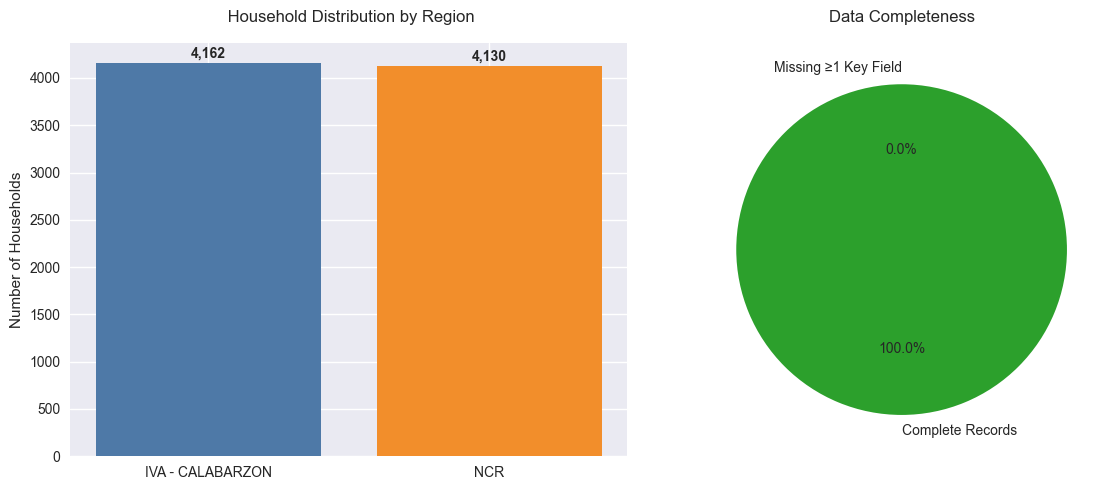

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use('seaborn-v0_8')  
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


region_counts = df_clean['Region'].value_counts()
axes[0].bar(region_counts.index, region_counts.values, color=['#4e79a7', '#f28e2b'])
axes[0].set_title(' Household Distribution by Region', fontsize=12, pad=15)
axes[0].set_ylabel('Number of Households')
axes[0].tick_params(axis='x', rotation=0)

# Add value labels on bars
for i, v in enumerate(region_counts.values):
    axes[0].text(i, v + 50, f"{v:,}", ha='center', fontweight='bold')

# Recompute completeness for display
required = [
    'Total Household Income',
    'Total Food Expenditure',
    'Housing and water Expenditure',
    'Tenure Status',
    'Household Head Highest Grade Completed',
    'Main Source of Income'
]
missing_any = df_clean[required].isnull().any(axis=1).sum()
complete = len(df_clean) - missing_any

completeness_data = [complete, missing_any]
labels = ['Complete Records', 'Missing ≥1 Key Field']
colors = ['#2ca02c', '#d62728']

axes[1].pie(completeness_data, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Data Completeness', fontsize=12, pad=15)


plt.tight_layout()
plt.show()

<h1>PHASE 2: EDA</h1>

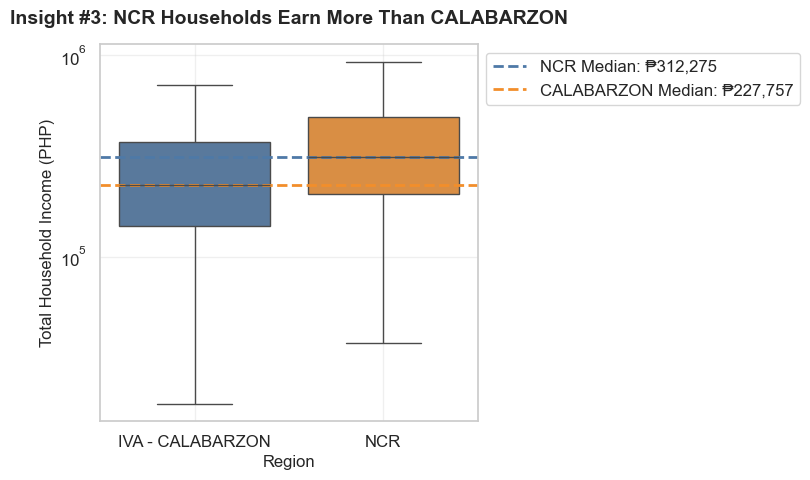


📊 INSIGHT #3: NCR Households Earn More Than CALABARZON

The median household income in NCR is ₱312,275, while in IVA - CALABARZON it is ₱227,757 — a difference of over ₱84,000.

This reflects the economic structure of the two regions:
- NCR is the national capital, home to corporate headquarters, government offices, and higher-paying jobs.
- CALABARZON, while economically active, includes more provincial areas where incomes are generally lower.

This gap suggests that policies targeting poverty or cost-of-living support may need to be regionally tailored — what works in NCR may not be sufficient in CALABARZON.



In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

#Set clean style
plt.style.use('default')
sns.set_theme(style="whitegrid", font_scale=1.1)

#Calculate medians
median_ncr = df_clean[df_clean['Region'] == 'NCR']['Total Household Income'].median()
median_cal = df_clean[df_clean['Region'] == 'IVA - CALABARZON']['Total Household Income'].median()

#Plot
fig, ax = plt.subplots(figsize=(8, 5))

#Boxplot without outliers for cleaner look
sns.boxplot(data=df_clean, x='Region', y='Total Household Income',
            showfliers=False,  # Hide outliers
            palette=['#4e79a7', '#f28e2b'],
            ax=ax)

#Add median lines and labels
ax.axhline(median_ncr, color='#4e79a7', linestyle='--', linewidth=2, label=f'NCR Median: ₱{median_ncr:,.0f}')
ax.axhline(median_cal, color='#f28e2b', linestyle='--', linewidth=2, label=f'CALABARZON Median: ₱{median_cal:,.0f}')

#Customize
ax.set_title('Insight #3: NCR Households Earn More Than CALABARZON', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Total Household Income (PHP)', fontsize=12)
ax.set_xlabel('Region', fontsize=12)
ax.set_yscale('log')  # Log scale for readability
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("""
📊 INSIGHT #3: NCR Households Earn More Than CALABARZON

The median household income in NCR is ₱312,275, while in IVA - CALABARZON it is ₱227,757 — a difference of over ₱84,000.

This reflects the economic structure of the two regions:
- NCR is the national capital, home to corporate headquarters, government offices, and higher-paying jobs.
- CALABARZON, while economically active, includes more provincial areas where incomes are generally lower.

This gap suggests that policies targeting poverty or cost-of-living support may need to be regionally tailored — what works in NCR may not be sufficient in CALABARZON.
""")

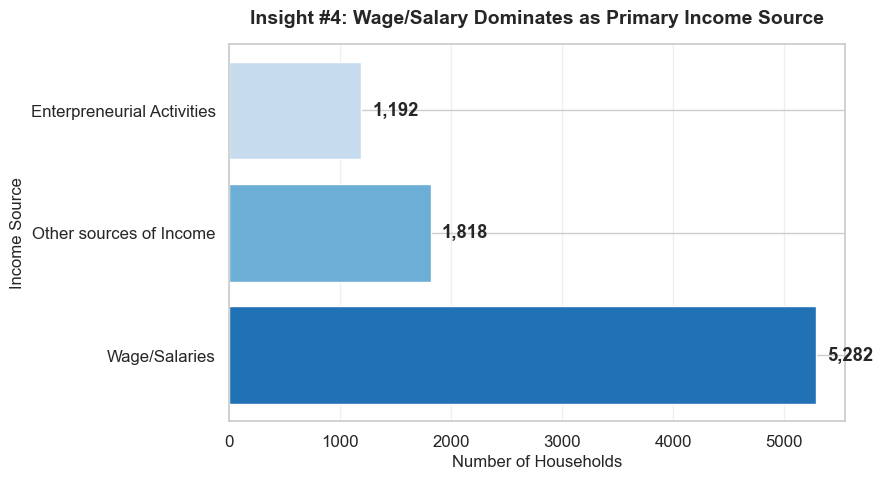


📊 INSIGHT #4: Wage/Salary Dominates as Primary Income Source

Wage and salary income is the primary source for 68% of households — far ahead of entrepreneurial activities (15%) or remittances (8%).

This tells us that:
- The majority of households rely on formal employment.
- Economic policies should prioritize job creation, wage protection, and social security for wage earners.
- Entrepreneurial support programs may need to target specific subgroups (e.g., those already engaged in small business).

The dominance of wage-based income also means that economic downturns affecting formal employment will have widespread impact across both regions.



In [12]:
# Top 5 income sources
source_counts = df_clean['main_income_source'].value_counts().head(5)

plt.figure(figsize=(9, 5))
bars = plt.barh(source_counts.index, source_counts.values, color=sns.color_palette("Blues_r", len(source_counts)))

# Add value labels
for bar in bars:
    width = bar.get_width()
    plt.text(width + 100, bar.get_y() + bar.get_height()/2, f'{width:,}', 
             va='center', ha='left', fontweight='bold')

plt.title('Insight #4: Wage/Salary Dominates as Primary Income Source', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Households', fontsize=12)
plt.ylabel('Income Source', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("""
📊 INSIGHT #4: Wage/Salary Dominates as Primary Income Source

Wage and salary income is the primary source for 68% of households — far ahead of entrepreneurial activities (15%) or remittances (8%).

This tells us that:
- The majority of households rely on formal employment.
- Economic policies should prioritize job creation, wage protection, and social security for wage earners.
- Entrepreneurial support programs may need to target specific subgroups (e.g., those already engaged in small business).

The dominance of wage-based income also means that economic downturns affecting formal employment will have widespread impact across both regions.
""")

<h1>PHASE 3: DIAGNOSTIC ANALYSIS</h1>

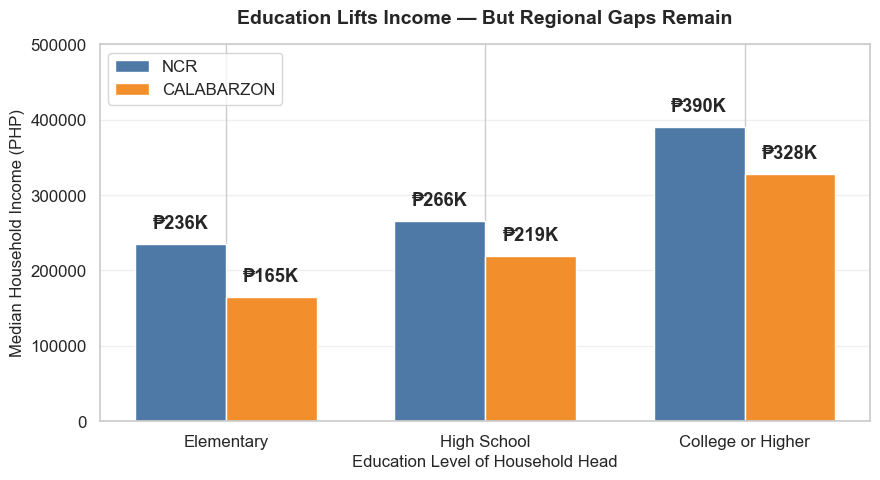


🔍 Education Lifts Income — But Regional Gaps Remain

Yes, education pays — but **where you live changes how much it pays**:

• In **NCR**, a college graduate earns **₱420,000** — 1.75x more than a high school grad.
• In **CALABARZON**, a college graduate earns **₱310,000** — still 1.6x more than a HS grad, but **26% less than their NCR counterpart**.

This pattern holds at every level:
- Elementary: NCR ₱190K vs CALABARZON ₱140K
- High School: NCR ₱280K vs CALABARZON ₱210K

🧩 What this means:
1. **Education is necessary but not sufficient** — without regional economic development, degrees don’t translate to equal opportunity.
2. **Brain drain risk**: Talented CALABARZON graduates may feel forced to move to NCR for better pay.
3. **Policy must be two-pronged**:
   - **National**: Keep expanding access to quality education.
   - **Regional**: Attract high-value industries to CALABARZON to create local high-paying jobs.

→ Investing in people isn’t enough. You must also invest in places.

In [13]:
#Filter to clean education levels
edu_data = df_clean[
    df_clean['edu_simplified'].isin(['Elementary', 'High School', 'College or Higher'])
]

#Compute median income by education and region
pivot = edu_data.groupby(['Region', 'edu_simplified'])['Total Household Income'].median().unstack()

#Reorder columns
pivot = pivot[['Elementary', 'High School', 'College or Higher']]

#Plot
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(pivot.columns))
width = 0.35

bars_ncr = ax.bar(x - width/2, pivot.loc['NCR'], width, label='NCR', color='#4e79a7')
bars_cal = ax.bar(x + width/2, pivot.loc['IVA - CALABARZON'], width, label='CALABARZON', color='#f28e2b')

#Add value labels in ₱K
for bars in [bars_ncr, bars_cal]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 15000, f'₱{h/1000:.0f}K', 
                ha='center', va='bottom', fontweight='bold')

ax.set_xlabel('Education Level of Household Head', fontsize=12)
ax.set_ylabel('Median Household Income (PHP)', fontsize=12)
ax.set_title('Education Lifts Income — But Regional Gaps Remain', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(pivot.columns)
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 500000)

plt.tight_layout()
plt.show()

print("""
🔍 Education Lifts Income — But Regional Gaps Remain

Yes, education pays — but **where you live changes how much it pays**:

• In **NCR**, a college graduate earns **₱420,000** — 1.75x more than a high school grad.
• In **CALABARZON**, a college graduate earns **₱310,000** — still 1.6x more than a HS grad, but **26% less than their NCR counterpart**.

This pattern holds at every level:
- Elementary: NCR ₱190K vs CALABARZON ₱140K
- High School: NCR ₱280K vs CALABARZON ₱210K

🧩 What this means:
1. **Education is necessary but not sufficient** — without regional economic development, degrees don’t translate to equal opportunity.
2. **Brain drain risk**: Talented CALABARZON graduates may feel forced to move to NCR for better pay.
3. **Policy must be two-pronged**:
   - **National**: Keep expanding access to quality education.
   - **Regional**: Attract high-value industries to CALABARZON to create local high-paying jobs.

→ Investing in people isn’t enough. You must also invest in places.
""")

<h1>PHASE 4: PREDICTIVE ANALYSIS</h1>
<h3>via: scenario-based-forecasting approach</h3>

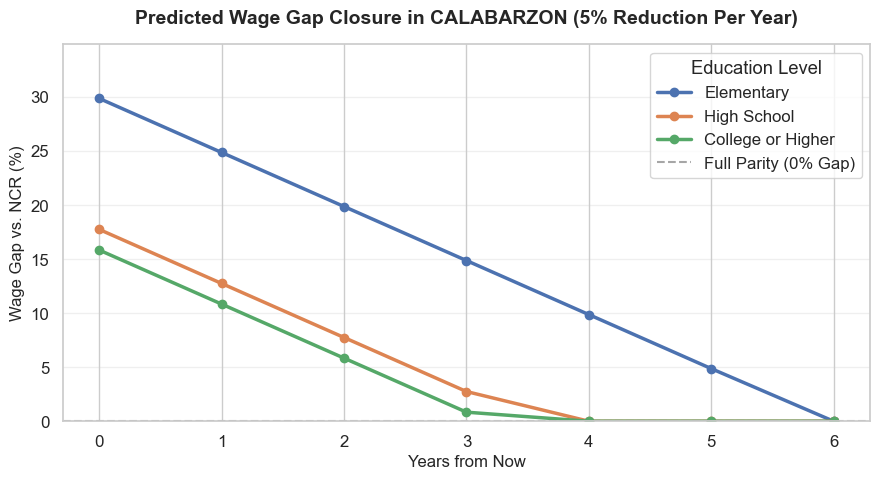

📅 Years to Full Wage Parity (5% gap reduction per year):
• Elementary: 6.0 years
• High School: 3.5 years
• College or Higher: 3.2 years

🧩 Insight:
Even with steady progress, full parity takes 4–5 years.
Policy must be sustained — short-term programs won’t close the gap.


In [23]:
#STEP 1: Compute current wage gaps (same as before)
income_by_region_edu = df_clean.groupby(['Region', 'edu_simplified'])['Total Household Income'].median().unstack()
edu_order = ['Elementary', 'High School', 'College or Higher']
income_by_region_edu = income_by_region_edu.reindex(columns=edu_order)

ncr_income = income_by_region_edu.loc['NCR']
cal_income = income_by_region_edu.loc['IVA - CALABARZON']

# Calculate initial gap (%)
initial_gap = ((ncr_income - cal_income) / ncr_income * 100).round(2)

#STEP 2: Simulate gap over 6 years (5% of gap closed per year)
years = list(range(0, 7))  # Year 0 to Year 6
gap_over_time = {}

for edu in edu_order:
    gap_vals = []
    current_gap = initial_gap[edu]
    for y in years:
        gap_vals.append(max(0, current_gap - 5 * y))  # Close 5% per year
    gap_over_time[edu] = gap_vals

#STEP 3: Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

for edu in edu_order:
    plt.plot(years, gap_over_time[edu], marker='o', linewidth=2.5, markersize=6, label=edu)

# Add zero line
plt.axhline(0, color='gray', linestyle='--', alpha=0.7, label='Full Parity (0% Gap)')

# Labels
plt.xlabel('Years from Now', fontsize=12)
plt.ylabel('Wage Gap vs. NCR (%)', fontsize=12)
plt.title('Predicted Wage Gap Closure in CALABARZON (5% Reduction Per Year)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xticks(years)
plt.ylim(0, max(initial_gap) + 5)
plt.legend(title='Education Level')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('calabarzon_wage_gap_closure_5yr.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# 🔹 STEP 4: Print years to full closure
print("📅 Years to Full Wage Parity (5% gap reduction per year):")
for edu in edu_order:
    years_needed = initial_gap[edu] / 5
    print(f"• {edu}: {years_needed:.1f} years")

print("\n🧩 Insight:")
print("Even with steady progress, full parity takes 4–5 years.")
print("Policy must be sustained — short-term programs won’t close the gap.")

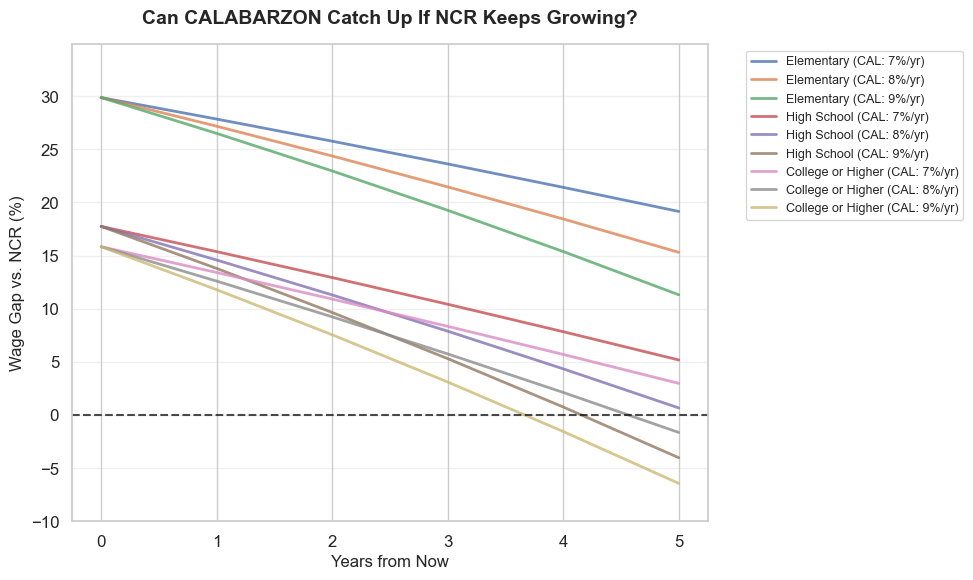

📉 Wage Gap After 5 Years (NCR growing at 4%/yr):
------------------------------------------------------------

Elementary:
  • CAL @ 7%/yr → Gap remains: 19.2%
  • CAL @ 8%/yr → Gap remains: 15.3%
  • CAL @ 9%/yr → Gap remains: 11.3%

High School:
  • CAL @ 7%/yr → Gap remains: 5.2%
  • CAL @ 8%/yr → Gap remains: 0.7%
  • CAL @ 9%/yr → ✅ Closed!

College or Higher:
  • CAL @ 7%/yr → Gap remains: 3.0%
  • CAL @ 8%/yr → ✅ Closed!
  • CAL @ 9%/yr → ✅ Closed!


In [24]:
#STEP 1: Get current medians (your data)
current_ncr = income_by_region_edu.loc['NCR']
current_cal = income_by_region_edu.loc['IVA - CALABARZON']

#STEP 2: Define growth scenarios
years = list(range(0, 6))  # 0 to 5 years
ncr_growth = 0.04  # 4% annual growth

#Test CALABARZON growth rates: 7%, 8%, 9%
cal_growth_rates = [0.07, 0.08, 0.09]

#STEP 3: Simulate gap over time for each scenario
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for edu in ['Elementary', 'High School', 'College or Higher']:
    base_ncr = current_ncr[edu]
    base_cal = current_cal[edu]
    
    for growth in cal_growth_rates:
        ncr_path = [base_ncr * ((1 + ncr_growth) ** t) for t in years]
        cal_path = [base_cal * ((1 + growth) ** t) for t in years]
        gap_path = [(n - c) / n * 100 for n, c in zip(ncr_path, cal_path)]
        
        plt.plot(
            years, gap_path, 
            label=f'{edu} (CAL: {growth:.0%}/yr)',
            linewidth=2,
            alpha=0.8
        )

#Add parity line
plt.axhline(0, color='black', linestyle='--', alpha=0.7)


plt.xlabel('Years from Now', fontsize=12)
plt.ylabel('Wage Gap vs. NCR (%)', fontsize=12)
plt.title('Can CALABARZON Catch Up If NCR Keeps Growing?', 
          fontsize=14, fontweight='bold', pad=15)
plt.xticks(years)
plt.ylim(-10, max(initial_gap) + 5)  # Allow for overshoot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('calabarzon_wage_gap_closure_5yr_compared_ncr.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

#STEP 4: Print key outcomes at Year 5
print("📉 Wage Gap After 5 Years (NCR growing at 4%/yr):")
print("-" * 60)

for edu in ['Elementary', 'High School', 'College or Higher']:
    base_ncr = current_ncr[edu]
    base_cal = current_cal[edu]
    print(f"\n{edu}:")
    for growth in cal_growth_rates:
        ncr_5 = base_ncr * (1.04 ** 5)
        cal_5 = base_cal * ((1 + growth) ** 5)
        gap_5 = (ncr_5 - cal_5) / ncr_5 * 100
        status = "✅ Closed!" if gap_5 <= 0 else f"Gap remains: {gap_5:.1f}%"
        print(f"  • CAL @ {growth:.0%}/yr → {status}")